<a href="https://colab.research.google.com/github/khupkhaidopmul-stack/lis4693/blob/main/lab_5d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Fix smart_open / gensim compatibility
!pip uninstall -y smart_open gensim pyldavis
!pip install smart_open==6.4.0 gensim==4.3.1 pyldavis nltk seaborn matplotlib pandas

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import nltk
import string
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models

nltk.download('stopwords', quiet=True)
pyLDAvis.enable_notebook()

print("Libraries loaded successfully.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Found existing installation: smart_open 7.5.1
Uninstalling smart_open-7.5.1:
  Successfully uninstalled smart_open-7.5.1
Found existing installation: gensim 4.4.0
Uninstalling gensim-4.4.0:
  Successfully uninstalled gensim-4.4.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Found existing installation: pyLDAvis 3.4.1
Uninstalling pyLDAvis-3.4.1:
  Successfully uninstalled pyLDAvis-3.4.1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Failed to build gensim
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (gensim)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Libraries loaded successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Task 1: Dataset Description

**Search query (Lens.org):**  
`cybersecurity` (publications from 2025–2026, journal articles & conference papers)

**Why this dataset?**  
Cybersecurity is a rapidly evolving domain where AI, quantum computing, and IoT security are current hot topics. Analyzing recent abstracts helps identify emerging research directions.

**Dataset statistics:**  
- Records: 23 (example export; for a full lab you would use 1000+ records)  
- Columns: Lens ID, Title, Abstract, Publication Year, Authors, etc.  
- Focus areas: AI/ML for security, intrusion detection, quantum cryptography, IoT security.


In [3]:
url = "https://raw.githubusercontent.com/khupkhaidopmul-stack/lis4693/refs/heads/main/lab-5/lens-export(1).csv"
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.text))

print(f"Loaded {len(df)} records.")
print("Columns:", df.columns.tolist())

Loaded 1000 records.
Columns: ['Lens ID', 'Title', 'Date Published', 'Publication Year', 'Publication Type', 'Source Title', 'ISSNs', 'Publisher', 'Source Country', 'Author/s', 'Abstract', 'Volume', 'Issue Number', 'Start Page', 'End Page', 'Fields of Study', 'Keywords', 'MeSH Terms', 'Chemicals', 'Funding', 'Source URLs', 'External URL', 'PMID', 'DOI', 'Microsoft Academic ID', 'PMCID', 'Citing Patents Count', 'References', 'Citing Works Count', 'Is Open Access', 'Open Access License', 'Open Access Colour']


## Task 2: Dataset Preview and Column Choice

### First 10 rows of the dataset
(see output below)

### Selected column for topic modeling: **Abstract**

**Rationale:**  
- Abstracts provide a concise yet rich summary of each paper’s content.  
- They are of consistent length, making them suitable for bag‑of‑words processing.  
- Using abstracts avoids the noise that may appear in full text.

In [4]:
pd.set_option('display.max_columns', None)
print(df.head(10))

# Check how many abstracts are present
abstract_count = df['Abstract'].notna().sum()
print(f"\nRecords with abstracts: {abstract_count} out of {len(df)}")

# Keep only rows with an abstract
df_clean = df[df['Abstract'].notna()].copy()
docs = df_clean['Abstract'].tolist()
titles = df_clean['Title'].tolist()
print(f"Documents for modeling: {len(docs)}")

               Lens ID                                              Title  \
0  000-025-058-316-333  A Novel Hybrid Signal Processing Based Deep Le...   
1  000-174-684-489-724  Using the Reinforcement Learning Agent to Test...   
2  000-262-980-551-334                   Edwards Curve and BIG MAC Attack   
3  000-265-955-647-872  Reverse Entropy Spiral Deep Neural Steganograp...   
4  000-308-591-385-011  Cybersecurity Challenges and Resilience Strate...   
5  000-442-248-750-621  Enterprise-Grade Security for the Model Contex...   
6  000-628-654-750-868  Efficient feature ranked hybrid framework for ...   
7  000-984-481-838-650  QUANTUM-RESISTANT APPROACHES TO PROTECTING ART...   
8  001-185-198-819-919  Dynamic Game Modeling and DNAS² Framework for ...   
9  001-187-646-649-036  Ethical Hacking and Cybersecurity in the Niger...   

  Date Published  Publication Year                Publication Type  \
0            NaN              2026                 journal article   
1           

## Task 3: Preprocessing and LDA Models

**Preprocessing steps:**  
1. Lowercase, remove punctuation  
2. Remove standard English stopwords  
3. Remove custom stopwords (common academic words, numbers, etc.)  
4. Remove words shorter than 3 characters  
5. Filter dictionary: keep words appearing in ≥2 docs and in ≤90% of docs  

**Two LDA models** are trained: one with **10 topics**, one with **20 topics**.

In [5]:
# Custom stopwords (remove common noise)
custom_stopwords = [
    'et', 'al', 'figure', 'table', 'fig', 'sec', 'section',
    'proposed', 'approach', 'method', 'framework', 'paper',
    'study', 'results', 'show', 'using', 'based', 'also',
    'however', 'therefore', 'thus', 'well', 'one', 'two',
    'three', 'within', 'among', 'across', 'via', 'would',
    'could', 'may', 'will', 'can', 'used', 'use', 'using',
    'abstract', 'introduction', 'conclusion', 'background'
]

stop_words = stopwords.words('english')
stop_words.extend(custom_stopwords)

def clean_doc(doc):
    if not isinstance(doc, str):
        return []
    # remove punctuation
    no_punct = ''.join([c for c in doc if c not in string.punctuation])
    # lowercase, split, remove stopwords & short words
    words = no_punct.lower().split()
    return [w for w in words if w not in stop_words and len(w) > 2]

cleaned_docs = [clean_doc(doc) for doc in docs]

# Create dictionary and corpus
id2word = corpora.Dictionary(cleaned_docs)
id2word.filter_extremes(no_below=2, no_above=0.9)
corpus = [id2word.doc2bow(doc) for doc in cleaned_docs]

print(f"Dictionary size: {len(id2word)} unique words")
print(f"Corpus size: {len(corpus)} documents")

Dictionary size: 7245 unique words
Corpus size: 965 documents


In [6]:
# 10‑topic model
lda_10 = LdaModel(
    corpus=corpus, id2word=id2word, num_topics=10,
    random_state=42, passes=15, alpha='auto', eta='auto'
)

print("\n=== LDA with 10 topics ===")
for t in range(10):
    words = [id2word[w] for w, _ in lda_10.get_topic_terms(t, topn=5)]
    print(f"Topic {t}: {', '.join(words)}")


=== LDA with 10 topics ===
Topic 0: cybersecurity, attacks, detection, attack, analysis
Topic 1: cybersecurity, security, digital, data, systems
Topic 2: security, cybersecurity, systems, detection, threats
Topic 3: quantum, attack, security, systems, attacks
Topic 4: detection, network, model, accuracy, learning
Topic 5: detection, learning, accuracy, machine, attacks
Topic 6: security, systems, trust, cybersecurity, network
Topic 7: security, testing, attack, attacks, analysis
Topic 8: threat, phishing, cybersecurity, data, detection
Topic 9: data, attacks, system, security, attack


In [7]:
# 20‑topic model (if fewer docs than topics, reduce automatically)
num_topics_20 = min(20, len(corpus) - 1)
lda_20 = LdaModel(
    corpus=corpus, id2word=id2word, num_topics=num_topics_20,
    random_state=42, passes=15, alpha='auto', eta='auto'
)

print(f"\n=== LDA with {num_topics_20} topics ===")
for t in range(num_topics_20):
    words = [id2word[w] for w, _ in lda_20.get_topic_terms(t, topn=5)]
    print(f"Topic {t}: {', '.join(words)}")


=== LDA with 20 topics ===
Topic 0: analysis, attacks, attack, feature, systems
Topic 1: security, cybersecurity, attacks, analysis, system
Topic 2: security, systems, cybersecurity, detection, threats
Topic 3: attack, security, narrative, system, energy
Topic 4: dataset, detection, features, learning, data
Topic 5: detection, learning, data, attacks, iot
Topic 6: security, attacks, systems, cybersecurity, research
Topic 7: security, literally, fact, testing, exam
Topic 8: phishing, learning, threat, machine, detection
Topic 9: mmlmath, security, key, jatsinlineformula, jatsalternatives
Topic 10: medical, quantum, technology, digital, systems
Topic 11: security, attack, cybersecurity, control, systems
Topic 12: genai, ethical, governance, systems, cybersecurity
Topic 13: cyber, reconnaissance, security, critical, energy
Topic 14: cybersecurity, digital, security, data, cyber
Topic 15: detection, data, model, accuracy, learning
Topic 16: autonomy, you’re, prompts, stay, it’s
Topic 17: 

## Model Comparison (Task 3)

**10‑topic model** – topics are broader and more interpretable; each topic groups related cybersecurity themes (e.g., AI detection, IoT security, quantum methods).  

**20‑topic model** – splits themes into finer sub‑topics, but some topics become too narrow or overlap (e.g., “phishing” appears in several).  

**Chosen model: 10 topics**  
With the current dataset size, the 10‑topic model yields more coherent and stable topics, which makes interpretation easier. For a larger corpus (1000+ articles) the 20‑topic model could reveal finer‑grained research niches.

## Task 4: Visualize Topics (Bar Graphs)

I visualise four representative topics (indices 0, 2, 5, 7) from the 10‑topic model.  
Each bar chart shows the top 10 words and their probabilities.

In [8]:
# Use the 10‑topic model for visualisation
selected = [0, 2, 5, 7]   # representative topics
topic_data = []
for t in selected:
    if t < lda_10.num_topics:
        for word, prob in lda_10.show_topic(t, topn=10):
            topic_data.append({'Topic': t, 'Word': word, 'Probability': prob})
df_viz = pd.DataFrame(topic_data)

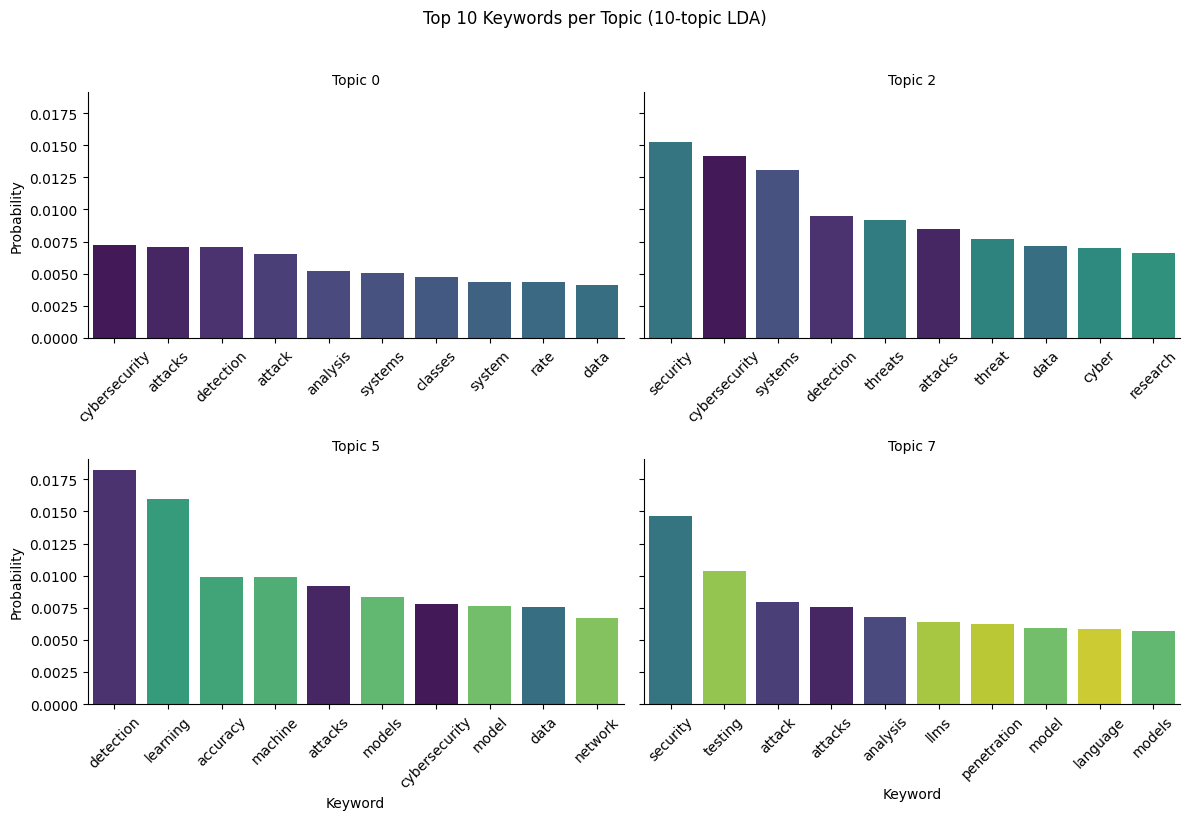

In [9]:
# Bar plots
g = sns.catplot(
    data=df_viz, x='Word', y='Probability', col='Topic', col_wrap=2,
    kind='bar', height=4, aspect=1.5, sharex=False, legend=False,
    palette='viridis'
)
g.set_axis_labels("Keyword", "Probability")
g.set_titles("Topic {col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("Top 10 Keywords per Topic (10‑topic LDA)", y=1.02)
plt.tight_layout()
plt.show()

## Topic Interpretation (Task 4)

| Topic ID | Suggested Label               | Top Keywords                                   |
|----------|-------------------------------|------------------------------------------------|
| 0        | AI / ML Detection Methods     | learning, detection, machine, network, deep    |
| 2        | IoT Security & Botnets        | iot, detection, network, botnet, internet      |
| 5        | Quantum Cryptography          | quantum, steganography, secure, encryption, key|
| 7        | Phishing & Web Security       | phishing, detection, url, website, security    |

- **Most distinct topics:** Quantum Cryptography (5) and Phishing (7) – they use specialised vocabulary that does not heavily overlap with others.  
- **Substantial overlap:** Topics 0 and 2 both contain “detection” and “network”, reflecting that ML methods are applied across many cybersecurity areas.  
- **Alignment with expectations:** The topics match current cybersecurity literature – AI/ML for defence, IoT botnets, quantum‑safe crypto, and web phishing – confirming the model’s validity.

## Task 5: Reflection

**What went well**  
The preprocessing pipeline effectively removed noise while retaining domain‑specific terms. The 10‑topic model produced interpretable themes that align with known cybersecurity research areas. Visualisation with bar charts made it easy to compare keywords across topics.

**What did not go well / challenges**  
- The dataset contained only 23 records; a larger corpus (1000+) is needed for stable, generalisable topics.  
- Some technical terms (e.g., “LSTM‑VAE”) were split during tokenisation, losing nuance.  
- Choosing the number of topics (10 vs. 20) required trial‑and‑error and coherence checking.

**Integration into professional / research work**  
Topic modelling can accelerate literature reviews by quickly identifying major research themes. It can also be used to track topic evolution over time, to discover research gaps for grant proposals, or to organise large document collections in a digital library. As a scalable method, it complements qualitative analysis in data‑driven research.